In [1]:
import numpy as np 
import pandas as pd

import gurobipy as gp
from gurobipy import GRB

import math
import random

from dataclasses import dataclass
from typing import Dict, Tuple, List, Optional

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import networkx as nx
from itertools import combinations

import glob
import os

import pickle

# Creating test instances from benchmark sets
#### In this part we generated test instances from the sets of Tsiligirides (1984) and Chao (1996). Four different base cases were considered; targets hidden far away from the starting node, targets hidden close to the starting node, targets hidden within various distances from the starting node and targets hidden randomly. 

In [2]:
@dataclass
class CreateInstance:
    coords: Dict[int, Tuple[float, float]]
    probabilities: Optional[np.ndarray] = None
    
def read_instance(path: str) -> CreateInstance:
    '''
    This function takes the path that guides to the benchmark set as argument and reads this instance.
    '''
    coords = {}

    with open(path, "r", encoding="utf-8") as file:
        lines = file.readlines()
        for i, raw in enumerate(lines[1:]):
            line = raw.strip()
            if not line or line == "EOF":
                continue
            x, y, _ = line.strip().split('\t')
            coords[int(i)] = (float(x), float(y))
    return CreateInstance(coords = coords)

def euc_dist(coords: Dict[int, Tuple[float, float]]) -> Dict[Tuple[int, int], float]:
    '''
    Calculates the Euclidean distance between all coordinates for the given instance and returns 
    a dictionary of the form {(i, j): d}. Here i and j are the vertices and d is the distance.
    '''
    dist = {}
    for i in range(len(coords)):
        xi, yi = coords[i]
        for j in range(i + 1, len(coords)):
            xj, yj = coords[j]
            dist[(i, j)] = math.hypot(xi - xj, yi - yj)
    return dist

def set_prob(n_targets: int, 
             coords: Dict[int, Tuple[float, float]],
             seed: int=42,
             split_size: int=5,
             distribution = str) -> np.ndarray:
    '''
    This function is used to create the various test instances, distributing targets across the nodes based on 
    generated probabilities. It takes the number of targets, coordinates, seed, splitsize 
    and base case as arguments. The split_size is only relevant for the separated case, as it is used to 
    divide the ordered list of distances into a specific number of parts.
    '''
    p = np.zeros((n_targets, len(coords))) # Initialize the probability matrix
    np.random.seed(seed)
    dist = euc_dist(coords)
    vertices = len(coords)
    depot_neighbors = [(key, value) for key, value in dist.items() if 0 in key] 
    depot_neighbors.sort(key=lambda tup: tup[1]) # Order the vertices based on their distance from the starting point 

    if distribution == "separated":
        region = depot_neighbors
        area = [j for (i, j),_ in region]
        clusters = np.array_split(area, split_size) # Divide the ordered vertices into separate parts
        active_clusters = np.random.choice([*range(len(clusters))], size=5, replace=False) # Randomly take 5 parts
        for t in range(n_targets):
            p[t, clusters[active_clusters[t]]] = 1/len(clusters[active_clusters[t]]) 
            # Distribute the probability mass over the cluster for each target
        return p 
            
    if distribution == "far": 
        region = depot_neighbors[round(vertices/2):]
        
    if distribution == "close":
        region = depot_neighbors[:round(vertices/2)]
        
    if distribution == "random":
        region = depot_neighbors
        for t in range(n_targets):
            area = [j for (i, j),_ in region]
            active_nodes = np.random.randint(3, round(len(area)/2)) 
            nodes = np.random.choice(area, size=active_nodes, replace=False)
            p[t, nodes] = 1/active_nodes 
            # Targets are randomly hidden at a minimum of 3 vertices and a maximum of half the total number of vertices.
        return p
        
        
    area = [j for (i, j),_ in region] # Note that the region here belongs to the class "far" or "close"
    for t in range(n_targets):
        active_nodes = np.random.randint(3, round(len(area)/2))
        central_node = np.random.choice(area) # For each target pick a random node and find the closest vertices to this node
        neighbors = [(key, value) for key, value in dist.items() if central_node in key and 0 not in key]
        neighbors.sort(key=lambda tup: tup[1]) 
        nearest = neighbors[:active_nodes] # Pick the closest number of active nodes 
        nodes = [j if i == central_node else i for (i, j), _ in nearest] 
        
        weights = np.random.rand(active_nodes) 
        weights /= weights.sum() # Give a random weight to the chosen active nodes such that it adds up to 1 for each target
        
        p[t, nodes] = weights
        
    return p

In [9]:
path = r"‪C:\Thesis Econometrics\Instances\tsiligirides_problem_1_budget_15.txt".strip("\u202a") # Path to file with benchmark sets
inst = read_instance(path)
coords = inst.coords

In [12]:
n_targets = 5
seed = 21
location = "separated"
split_size=6
prob = set_prob(n_targets = n_targets, coords = inst.coords, seed=seed, split_size=split_size, distribution=location)

In [97]:
def save_instance(coords: Dict[int, Tuple[float, float]], 
                   prob: np.ndarray, 
                   Id: int,
                   location: str) -> pd.DataFrame:
    '''
     This function is used to save the generated test instance as a csv file. 
     Specifically, we store the coordinates of each vertex, as well as the probabilities of targets being located there.
    '''

    nodes = sorted(coords.keys())  
    
    df = pd.DataFrame({
        "node": nodes,
        "x": [coords[i][0] for i in nodes],
        "y": [coords[i][1] for i in nodes],
    })
    
    n_targets = prob.shape[0]
    for t in range(n_targets):
        df[f"p{t+1}"] = prob[t, nodes]  
    
    filename = f"tsiligirides1_targets{n_targets}_" + location + f"{Id}.csv"
    path = f"C:/Thesis Econometrics/Test Instances/{filename}"
    df.to_csv(path, index=False)
    return df
# save_instance(coords, prob, seed, location)

# Always run the dataclass code and the MT-SAP-Greedy (until figures) code below 

In [3]:
@dataclass
class Instance:
    df: pd.DataFrame
    coords: Dict[int, Tuple[float, float]] = None
    probabilities: Optional[np.ndarray] = None
    
def read_test_instance(path: str, n_targets: int) -> Instance:
    df = pd.read_csv(path)
    inst = Instance(df=df)
    inst.coords = coords(df)
    inst.probabilities = probs(df, n_targets)
    return inst

def coords(df: pd.DataFrame) -> Dict[Tuple[int, int], float]:
    coords = {}
    for i in df.index:
        coords[int(i)] = (df.loc[i, "x"], df.loc[i, "y"])
    return coords

def euc_dist(coords: Dict[int, Tuple[float, float]]) -> Dict[Tuple[int, int], float]:
    dist = {}
    for i in range(len(coords)):
        xi, yi = coords[i]
        for j in range(i + 1, len(coords)):
            xj, yj = coords[j]
            dist[(i, j)] = math.hypot(xi - xj, yi - yj)
    return dist

def tree_dist(dist: Dict[Tuple[int, int], float]) -> Dict[Tuple[int, int], float]:
    '''
    Calculates the distances for the minimum spanning tree of the given test instance.
    This only becomes relevant later, when we look at MT-GSAP on trees.
    '''
    sym_dist = {}
    for (i, j), d in dist.items():
        if i != 0: 
            sym_dist[i, j] = d
            sym_dist[j, i] = d 
        else:
            sym_dist[i, j] = d
            
    G = nx.Graph() # Initialize the graph 
    for (i, j), d in sym_dist.items():
        G.add_edge(i, j, weight=d)
    T = nx.minimum_spanning_tree(G) # Find the minimum spanning tree using NetworkX
    spl = dict(nx.all_pairs_dijkstra_path_length(T)) # Find the shortest paths along the tree 
    sp_tree = {}
    for i in range(len(spl)):
        for v, d in spl[i].items():
            if v != 0 and i != v:
                sp_tree[i, v] = d
    return sp_tree

def probs(df: pd.DataFrame, n_targets: int) -> np.ndarray:
    prob_cols = [f"p{t+1}" for t in range(n_targets)]
    return df[prob_cols].to_numpy().T 
    

# MT-SAP 
#### In the multi-target search allocation problem, we do not yet take travel costs into account. In this section we use Gurobi to obtain a best bound for the corresponding mixed integer non linear program and we apply the MT-SAP-Greedy algorithm. We use the locations and probabilities from the test instances in the previous section, without considering distances.

In [4]:
def SAP_gurobi(inst: Instance, B: float, gamma: float, 
                  n_targets: int, softlimit: float = 90, hardlimit: float = 90) -> dict:
    
    cds = inst.coords
    prob = inst.probabilities
    dist = euc_dist(cds)
    
    sym_dist = {} 
    for (i, j), d in dist.items():
        if i != 0:
            sym_dist[i, j] = d
            sym_dist[j, i] = d
        else:
            sym_dist[i, j] = d
    
    V = [i for i in cds.keys() if i != 0]

    m = gp.Model("SAP")
    m.setParam("OutputFlag", 0)  # No debugging while running

    b = m.addVars(V, vtype=gp.GRB.INTEGER, name="b") # The number of searches at vertex i are denoted by b_i
    q = m.addVars(n_targets, lb=0, ub=1, vtype=gp.GRB.CONTINUOUS, name="q") # The probability of detecting target t

    fvals = [1 - (1-gamma)**k for k in range(B+1)] 
    # The fvalues list calculates the detection probability for every number of searches, given that the target is at the vertex
    
    y = m.addVars(V, lb=0, ub=1, name="y") # This variable is used in the piece-wise linear constraint below

    '''
    The following links the b_i searches to a detection probability (given a target is located there) denoted
    by y_i for every vertex i
    '''
    for i in V: 
        m.addGenConstrPWL(
            b[i],
            y[i],
            list(range(B+1)),
            fvals
        )
        
    for t in range(n_targets):
        m.addConstr(
            q[t] <= gp.quicksum(y[i] * prob[t, i] for i in V) # Calculates the probability of detecting target t
        )
        
    u = m.addVars(n_targets, lb=0, ub=1, name="u")  # Variable to store the probability that target t is not detected

    for i in range(n_targets):
        m.addConstr(u[i] == 1 - q[i]) 

    prod_vars = []

    '''
    Below, we recursively calculate the probability of detecting no target denoted by "prod" 
    and we maximize (1-prod)
    '''

    p = m.addVar(lb=0, ub=1, name="p_1")
    m.addQConstr(p == u[0] * u[1])

    prod_vars.append(p)

    for i in range(2, n_targets):

        new_p = m.addVar(lb=0, ub=1, name=f"p_{i}")

        m.addQConstr(new_p == prod_vars[-1] * u[i])

        prod_vars.append(new_p)

    prod = prod_vars[-1]

    m.setObjective(1 - prod, GRB.MAXIMIZE)

    m.addConstr(gp.quicksum(b[i] for i in V) <= B) # Budget constraint

    def softtime(model, where):
        if where == gp.GRB.Callback.MIP:
            runtime = model.cbGet(gp.GRB.Callback.RUNTIME)
            objbst = model.cbGet(gp.GRB.Callback.MIP_OBJBST)
            objbnd = model.cbGet(gp.GRB.Callback.MIP_OBJBND)
            if runtime > softlimit:
                model.terminate()
    # This sets the maximum execution time            
    m.setParam('TimeLimit', hardlimit)
    
    m.optimize(softtime)
    
    result = {
        "status": m.Status,
        "runtime": m.Runtime,
        "objective": m.ObjVal if m.SolCount > 0 else None,
        "best_bound": m.ObjBound,
        "mip_gap": m.MIPGap if m.SolCount > 0 else None,
        "n_targets": n_targets,
        "B": B,
        "gamma": gamma,
    }

    result["allocation"] = [0] + [b[i].x for i in V]
    return result

In [5]:
path = r"C:\Thesis Econometrics\Benchmark Instances\tsiligirides1_targets5_random21.csv"
n_targets = 2
inst = read_test_instance(path, n_targets)
cds = inst.coords
prob = inst.probabilities

In [6]:
B = 5
gamma = 0.8
V = [i for i in cds.keys() if i != 0]

results = SAP_gurobi(inst, B, gamma, n_targets, 60, 60)

Set parameter Username
Set parameter LicenseID to value 2787293
Academic license - for non-commercial use only - expires 2027-03-04


### MT-SAP-Greedy

In [7]:
def evaluate_obj(b, gamma, V, n_targets, prob):
    '''
    This function simply calculates the objective value, i.e. the probability of detecting at least one target for
    a given search allocation vector b. 
    '''
    prod = 1
    for t in range(n_targets):
        q_t = 0 
        for i in V: 
            q_t += (1-(1-gamma)**b[i]) * prob[t, i]
        q_t = min(q_t, 1.0)
        prod = prod * (1-q_t)
    return 1 - prod 

In [8]:
def maximum_gain(b, gamma, V, n_targets, prob):
    '''
    Here, we determine at which vertex the gain is maximized, given the current allocation of search effort.
    '''
    b_prev = b.copy()
    gains = []
    for i in V:
        b[i] = b[i] + 1
        gain = (evaluate_obj(b, gamma, V, n_targets, prob)-
                evaluate_obj(b_prev, gamma, V, n_targets, prob))
        gains.append(gain)
        b[i] = b[i] - 1
    best_idx = np.argmax(gains)
    return V[best_idx]

In [9]:
def greedy(B, gamma, V, n_targets, prob):
    '''
    The MT-SAP-Greedy algorithm
    '''

    b = np.zeros(len(V) + 1)
    cost = 0
    searches = []
    while cost < B: # Iterating until the budget B is reached 
        new_search = maximum_gain(b, gamma, V, n_targets, prob)
        cost += 1
        b[new_search] = b[new_search] + 1
        
        searches.append(new_search)
    allocation = b # The final search allocation vector        
    return searches, cost, allocation
    
searches, cost, allocation = greedy(B, gamma, V, n_targets, prob)
searches, cost, allocation

([1, 2, 4, 6, 7],
 5,
 array([0., 1., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

In [10]:
evaluate_obj(allocation, gamma, V, n_targets, prob)

0.5111111111111108

### Figures

In [28]:
benchmark_dir = r"C:\Thesis Econometrics\Benchmark Instances" # Put the directory with the test instances
files = glob.glob(os.path.join(benchmark_dir, "*.csv"))

In [29]:
# We cosider different problem paramters
configs = [
    {"gamma": 0.3, "B": 5, "title": r"$\gamma=0.3$, $B=5$"},
    {"gamma": 0.3, "B": 10, "title": r"$\gamma=0.3$, $B=10$"},
    {"gamma": 0.3, "B": 20, "title": r"$\gamma=0.3$, $B=20$"},
    {"gamma": 0.8, "B": 5, "title": r"$\gamma=0.8$, $B=5$"},
    {"gamma": 0.8, "B": 10, "title": r"$\gamma=0.8$, $B=10$"},
    {"gamma": 0.8, "B": 20, "title": r"$\gamma=0.8$, $B=20$"},
]

target_counts = [2, 3, 4, 5]
instance_class = "tsiligirides1"  


def collect_gaps(instance_class: str, gamma: float, B: float, n_targets: int, files: list) -> dict:
 
    sg_gaps = []
    n_opt = 0
    for filepath in files: # Iterates over all test instances generated from the given instance class
        filename = os.path.basename(filepath)
        if instance_class not in filename:
            continue
        
        inst = read_test_instance(filepath, n_targets)
        cds = inst.coords
        prob = inst.probabilities
        V = [i for i in cds.keys() if i != 0]
        dist = euc_dist(cds)
        
        gurobi_result = SAP_gurobi(inst, B, gamma, n_targets, 90, 90) # Obtain the best bound within 90 seconds using Gurobi 
        sg_path, sg_cost, sg_allocation = greedy(B, gamma, V, n_targets, prob) # MT-SAP-Greedy solution
        if gurobi_result['status'] == GRB.OPTIMAL:
            n_opt += 1
        bb = gurobi_result["best_bound"] 
        sg_val = evaluate_obj(sg_allocation, gamma, V, n_targets, prob)


        sg_gaps.append((bb - sg_val) / bb) # Calculate the gap between the best bound and greedy solution
    
    return {"sg": sg_gaps}, {"n_opt": n_opt}


all_results = []
n_opt_results = []
for cfg in configs:
    per_target = {}
    opt_reached = {}
    for n_targets in target_counts:
        gps = collect_gaps(
            instance_class, cfg["gamma"], cfg["B"], n_targets, files
        )
        per_target[n_targets] = gps[0]
        opt_reached[n_targets] = gps[1]
        
    all_results.append(per_target)
    n_opt_results.append(opt_reached)

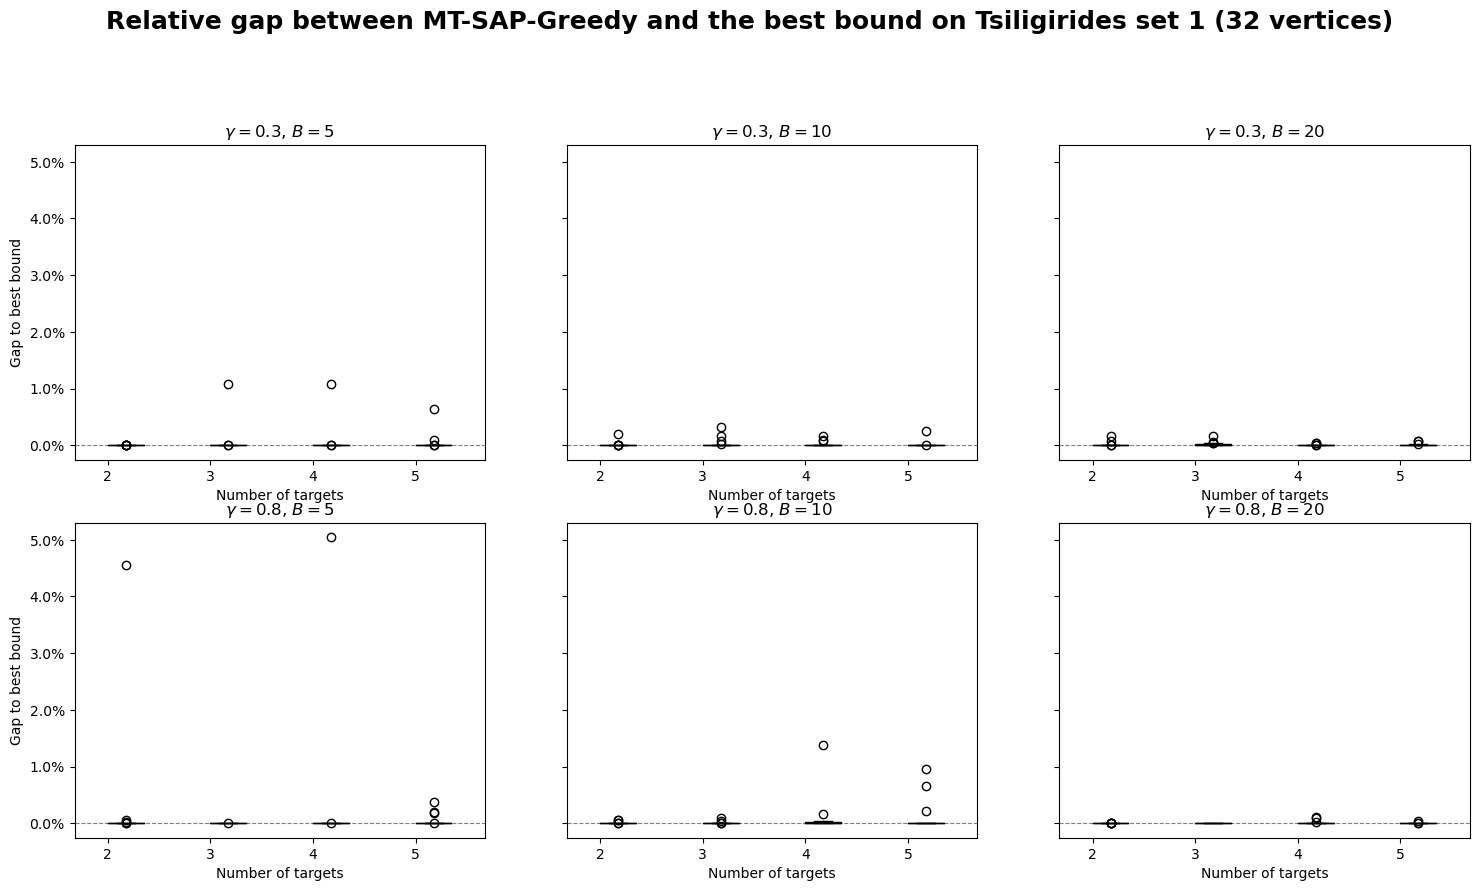

In [30]:
'''
In the following, we present the results for each configuration using box plots
'''
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True)
axes = axes.flatten()

box_width = 0.35

positions_sg = np.arange(len(target_counts)) + box_width / 2

for idx, (ax, cfg, per_target) in enumerate(zip(axes, configs, all_results)):
    sg_data = [per_target[n]["sg"] for n in target_counts]
    
    bp_sg = ax.boxplot(sg_data, positions=positions_sg, widths=box_width,
                        patch_artist=True, boxprops=dict(facecolor="#DD8452"),
                        medianprops=dict(color="black"))
    
    ax.set_xticks(np.arange(len(target_counts)))
    ax.set_xticklabels(target_counts)
    ax.set_xlabel("Number of targets")
    if idx % 3 == 0:
        ax.set_ylabel("Gap to best bound")
    ax.set_title(cfg["title"])
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))


fig.suptitle(
    "Relative gap between MT-SAP-Greedy and the best bound on Tsiligirides set 1 (32 vertices)",
    fontsize=18,
    fontweight="bold",   
    y=1.03
)

# # Save figure 
# plt.tight_layout()
# plt.savefig(f"SAP_gap_boxplots_{instance_class}.png", dpi=300, bbox_inches="tight")
plt.show()

# MT-GSAP
#### In the multi-target graph search allocation problem, we search for a search strategy/path that maximizes the probability of detecting at least one target. First, we show the mixed integer non linear program for MT-GSAP. Then, we present the Greedy Cost Benefit algorithm, which uses the path algorithm from Hoogeveen (1991) with an approximation guarantee of 3/2. Finally, we implemented the Simple Greedy algorithm. 

In [11]:
def GSAP_gurobi(inst: Instance, B: float, gamma: float, 
                  n_targets: int, softlimit: float = 90, hardlimit: float = 90) -> dict:
    
    cds = inst.coords
    prob = inst.probabilities
    dist = euc_dist(cds)
    
    sym_dist = {}
    for (i, j), d in dist.items():
        if i != 0:
            sym_dist[i, j] = d
            sym_dist[j, i] = d
        else:
            sym_dist[i, j] = d
    
    V = [i for i in cds.keys() if i != 0]
    T = range(n_targets)  
    
   
    m = gp.Model("G-SAP")
    m.setParam("OutputFlag", 0)  # No debugging while running
    
    x = m.addVars(sym_dist.keys(), vtype=gp.GRB.BINARY, name="x") # Binary variable for taking edge (i,j) or not
    b = m.addVars(V, vtype=gp.GRB.INTEGER, name="b") # Denotes the number of searches at vertex i 
    q = m.addVars(n_targets, lb=0, ub=1, vtype=gp.GRB.CONTINUOUS, name="q") # Variable for the detection probability q_t of each target t
    u = m.addVars(V, lb=1, ub=len(V), vtype=gp.GRB.INTEGER, name="u") # Used to order visits and prevent subtours
    
    '''
    The following links the b_i searches to a detection probability (given a target is located there) denoted
    by y_i for every vertex i. This is used to incorporate non-linearity into the model, in the same way as we did for MT-SAP.
    '''
    fvals = [1 - (1-gamma)**k for k in range(B+1)] 

    y = m.addVars(V, lb=0, ub=1, name="y")

    for i in V:
        m.addGenConstrPWL(
            b[i],
            y[i],
            list(range(B+1)),
            fvals
        )
    
    g = m.addVars(n_targets, lb=0, ub=1, name="g")

    for i in range(n_targets):
        m.addConstr(g[i] == 1 - q[i])

    prod_vars = []

    p = m.addVar(lb=0, ub=1, name="p_1")
    m.addQConstr(p == g[0] * g[1])

    prod_vars.append(p)

    for i in range(2, n_targets):

        new_p = m.addVar(lb=0, ub=1, name=f"p_{i}")

        m.addQConstr(new_p == prod_vars[-1] * g[i])

        prod_vars.append(new_p)

    prod = prod_vars[-1]

    # Eventually we maximize the probability of detecting at least one target.
    m.setObjective(1 - prod, GRB.MAXIMIZE)

    for t in range(n_targets):
        m.addConstr(
            q[t] <= gp.quicksum(y[i] * prob[t, i] for i in V)
        )

    # Ensure that we start from the starting vertex 0
    m.addConstr(gp.quicksum(x[i, j] for (i, j) in sym_dist.keys() if i == 0) == 1)

    # At most one edge going into vertex j 
    m.addConstrs(gp.quicksum(x[i, j] for (i, j) in sym_dist.keys() if j == node) <= 1 for node in V)

    # At most one edge leaving vertex i
    m.addConstrs(gp.quicksum(x[i, j] for (i, j) in sym_dist.keys() if i == node) <= 1 for node in V)

    # Everytime we leave a vertex, there has to be an edge going in 
    m.addConstrs(gp.quicksum(x[i, j] for (i, j) in sym_dist.keys() if i == node) <=
                gp.quicksum(x[i, j] for (i, j) in sym_dist.keys() if j == node) for node in V)

    # m.addConstrs(x[i, j] + x[j, i] <= 1 for (i, j) in dist.keys() if i != 0)

    # We may only allocate search effort to a vertex once it is visited
    m.addConstrs((b[node] <= B * gp.quicksum(x[i, j] for (i, j) in sym_dist.keys() if j == node)) for node in V)

    # The total search effort and distance traveled may not exceed the budget B
    m.addConstr(gp.quicksum(b[i] for i in V) + 
                 gp.quicksum(x[i, j] * sym_dist[i,j] for (i, j) in sym_dist.keys()) <= B)
    
    # The following orders the visited vertices in increasing order, such that subtours are prevented
    # For example, 2-3-4-2 is not possible since 4-2 is not smaller than -1 
    for (i, j) in sym_dist.keys():
        if i != 0 and j != 0:
            m.addConstr(u[i] - u[j] + len(V) * x[i, j] <= len(V) - 1)
        

    def softtime(model, where):
        if where == GRB.Callback.MIP:
            runtime = model.cbGet(GRB.Callback.RUNTIME)
            objbst = model.cbGet(GRB.Callback.MIP_OBJBST)
            objbnd = model.cbGet(GRB.Callback.MIP_OBJBND)
            if abs(objbst) > 1e-9:
                gap = abs(objbst - objbnd) / abs(objbst)
            else:
                gap = float("inf")
            if runtime > softlimit:
                model.terminate()
                
    # This sets the maximum execution time    
    m.setParam("TimeLimit", hardlimit)
    m.optimize(softtime)
    
    result = {
        "status": m.Status,
        "runtime": m.Runtime,
        "objective": m.ObjVal if m.SolCount > 0 else None,
        "best_bound": m.ObjBound,
        "mip_gap": m.MIPGap if m.SolCount > 0 else None,
        "n_targets": n_targets,
        "B": B,
        "gamma": gamma,
    }

    edges = []
    if m.SolCount > 0:
        for i, j in sym_dist.keys():
            if x[i, j].x > 0.5:
                edges.append((i, j))
    
    result["edges"] = edges
    result["allocation"] = [0] + [b[i].x for i in V]
    m.dispose()
    return result

In [12]:
path = r"C:\Thesis Econometrics\Benchmark Instances\tsiligirides1_targets5_far123.csv"
n_targets = 5
inst = read_test_instance(path, n_targets)

cds = inst.coords
prob = inst.probabilities
dist = euc_dist(cds)

In [13]:
sym_dist = {}
for (i, j), d in dist.items():
    if i != 0: 
        sym_dist[i, j] = d
        sym_dist[j, i] = d 
    else:
        sym_dist[i, j] = d
V = [i for i in cds.keys() if i != 0]

In [14]:
B = 30
gamma = 0.3 
results = GSAP_gurobi(inst, B, gamma, n_targets, 90, 90)
b = results["allocation"]
results["objective"]

0.9042744495129384

In [15]:
# The figure below shows the path obtained from gurobi within 90 seconds 

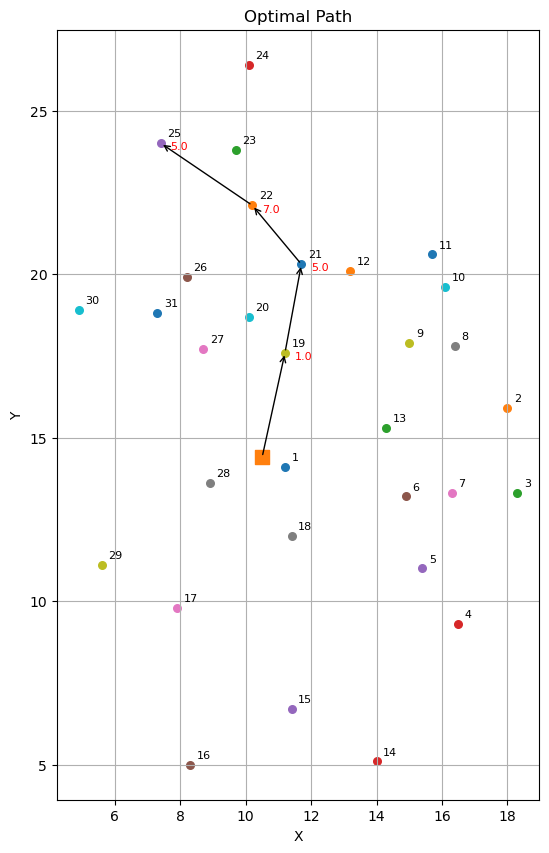

In [16]:
fig, ax = plt.subplots(figsize=(8, 10))

for node, (x_coord, y_coord) in cds.items():
    if node != 0:
        ax.scatter(x_coord, y_coord, s=30)
        ax.text(x_coord + 0.2, y_coord + 0.2, str(node), fontsize=8)

for i, j in results["edges"]:
    x1, y1 = cds[i]
    x2, y2 = cds[j]

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            lw=1,
        )
    )
    ax.text(x2+0.3, y2-0.2, str(b[j]), fontsize=8, color='r')

x0, y0 = cds[0]
ax.scatter(x0, y0, s=100, marker="s")

ax.set_title("Optimal Path")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
ax.set_aspect("equal")

plt.show()

### Greedy Cost Benefit (GCB)

In [17]:
def ConstructGraph(vertices, sym_dist):
    '''
    This function simply constructs the graph by adding all weighted edges between the vertices
    '''
    vertices.sort()
    edges = [edge for edge in combinations(vertices, 2)]
    G = nx.Graph()
    for e in edges: 
        G.add_edge(e[0], e[1], weight=sym_dist[e[0], e[1]]) 
    return G

In [18]:
def MST(current_set, new_vertex, sym_dist):
    '''
    Determines the minimum spanning tree on the current set with the new vertex
    '''
    vertices = current_set + [new_vertex]
    vertices.sort()
    
    G_tree = ConstructGraph(vertices, sym_dist)
    T = nx.minimum_spanning_tree(G_tree)
    
    return T

In [19]:
def PerfectMatching(Tree, sym_dist):
    '''
    This function determines the minimum weight perfect matching 
    '''
    deg = Tree.degree
    wrong_deg = []

    for i in Tree.nodes:
        if deg[i] % 2 != 0:
            wrong_deg.append(i)
    
    if deg[0] % 2 == 0:
        wrong_deg.insert(0, 0)
    elif deg[0] % 2 != 0:
        wrong_deg.remove(0)

    G_match = ConstructGraph(wrong_deg, sym_dist)
    for node in wrong_deg:
        G_match.add_edge(node, 1000, weight = 0) # This is a dummy edge to determine which vertex will be exposed in the minimum matching
    Matching = nx.min_weight_matching(G_match, "weight")
        
    return Matching

In [20]:
def ConstructMultiGraph(Tree, Matching, sym_dist):
    '''
    The idea behind the multigraph is that, after adding the edges of the perfect matching, 
    two edges can exist between the same nodes.
    '''
    MG = nx.MultiGraph()
    
    tree_edges = nx.get_edge_attributes(Tree, "weight")
    for edge in tree_edges:
        MG.add_edge(edge[0], edge[1], weight = tree_edges[edge[0], edge[1]])
    
    for u, v in Matching:
        if u != 1000 and v != 1000:
            MG.add_edge(u, v, weight = sym_dist[u, v])
            
    return MG

In [21]:
def EulerianPath(MultiGraph):
    '''
    Determines the Eulerianpath on the multigraph
    '''
    return nx.eulerian_path(MultiGraph, source=0)

In [22]:
def ShortestPath(current_set, new_vertex, sym_dist):
    '''
    Finally, this function combines all previous steps into the algorithm of Hoogeveen (1991) to determine 
    a path with an approximation ration of 3/2 compared to the optimal solution.
    '''
    Tree = MST(current_set, new_vertex, sym_dist) 
    
    Match = PerfectMatching(Tree, sym_dist)
    
    MG = ConstructMultiGraph(Tree, Match, sym_dist)
    
    EulerPath = list(EulerianPath(MG))
    
    NodeSequence = [EulerPath[0][0]] + [v for u, v in EulerPath]
    
    Shortcut = []
    for node in NodeSequence: 
        if node not in Shortcut:
            Shortcut.append(node)

    HamiltonianPath = []
    for i in range(len(Shortcut)-1):
        edge = Shortcut[i],Shortcut[i+1]
        HamiltonianPath.append(edge)
         
    return HamiltonianPath

In [23]:
def GCBGain(b, multiset, prev_cost, B, gamma, V, n_targets, prob, sym_dist):
    '''
    Here, we determine the vertex that gives the highest GCB-gain 
    '''
    b_prev = b.copy()
    gains = []
    path = list(set(multiset))
    
    for i in V: # We propose every vertex as a new search vertex and choose the best one
        b[i] = b[i] + 1 

        if i in path: 
            gain = i, (evaluate_obj(b, gamma, V, n_targets, prob)-
                       evaluate_obj(b_prev, gamma, V, n_targets, prob)), prev_cost + 1 
            # If i is already in the path the cost only increases with 1 
            gains.append(gain)
        else:
            HamilPath = ShortestPath(path, i, sym_dist) # Approximation to the shortest path
            NewCost = sum([sym_dist[i,j] for i,j in HamilPath]) + sum(b) 
            cost_diff = NewCost - prev_cost
            if NewCost <= B: 
                gain = i, (evaluate_obj(b, gamma, V, n_targets, prob)-
                           evaluate_obj(b_prev, gamma, V, n_targets, prob))/(cost_diff), NewCost
                gains.append(gain)
        b[i] = b[i] - 1
        
    best_gain = max(gains, key=lambda item: item[1]) # Choose the vertex with the heighest gain
    new_search, new_cost = best_gain[0], best_gain[2]
    return new_search, new_cost

In [24]:
def GCB(B, gamma, V, n_targets, prob, sym_dist):
    '''
    The final Greedy Cost Benefit algorithm
    ''' 

    b = np.zeros(len(V)+1)
    
    isolated_searches = [0] # Here, we determine the best single-vertex strategy
    for i in V:
        A = np.zeros(len(V)+1)
        remaining_budget = B - sym_dist[0, i]
        max_searches = math.floor(remaining_budget)
        A[i] = max_searches
        isolated_searches.append(evaluate_obj(A, gamma, V, n_targets, prob))
        
    prev_cost = 0
    # The multipath behaves more like a multiset that respectes the order in which vertices are added by the algorithm 
    multipath = [0] 
    while True: 
        new_search, new_cost = GCBGain(b, multipath, prev_cost, B, gamma, V, n_targets, prob, sym_dist)
        # We obtain the vertex that yields the best cost-benefit ratio together with the new cost
        if new_cost > B:
            break
            
        prev_cost = new_cost 
        b[new_search] = b[new_search] + 1 # Add the search to the search allocation vector 
        
        if new_search in multipath:
            idx = multipath.index(new_search)
            multipath.insert(idx, new_search)
        else:
            multipath.append(new_search)
            
    # Choose the best of the two solutions
    if evaluate_obj(b, gamma, V, n_targets, prob) >= max(isolated_searches): 
        final_path = ShortestPath(list(set(multipath))[:-1], list(set(multipath))[-1], sym_dist) # Determine final path
        costs = prev_cost
        allocation = b
    else:
        isolated_search = np.argmax(isolated_searches)
        n_searches = math.floor(B - sym_dist[0, isolated_search])
        costs =  n_searches + sym_dist[0, isolated_search]
        final_path = [0] + [isolated_search] * n_searches
        A = np.zeros(len(V)+1)
        A[isolated_search] = n_searches
        allocation = A
        
    return final_path, costs, allocation
final_path, cost, allocation = GCB(B, gamma, V, n_targets, prob, sym_dist)

In [25]:
final_path, cost, evaluate_obj(allocation, gamma, V, n_targets, prob)

([(0, 19), (19, 20), (20, 21), (21, 22)],
 29.437119392011194,
 0.8582831140397655)

### Simple Greedy

In [26]:
def sg_gain(b, current_v, path, gamma, V, n_targets, prob, dist):
    '''
    The Simple Greedy gain is calculated by the ratio between the marginal gain and the (travel + search cost)
    for the immediate move.
    '''
    b_prev = b.copy()
    gains = []
    for i in V:
        b[i] = b[i] + 1
        if i == current_v or i in path:
            # If the vertex appears already in the path we only pay search costs 
            gain = (evaluate_obj(b, gamma, V, n_targets, prob)-
                    evaluate_obj(b_prev, gamma, V, n_targets, prob)) 
            b[i] = b[i] - 1
        else: 
            if current_v < i: 
                gain = (evaluate_obj(b, gamma, V, n_targets, prob)-
                        evaluate_obj(b_prev, gamma, V, n_targets, prob))/(dist[current_v, i] + 1)
                b[i] = b[i] - 1
            else:
                gain = (evaluate_obj(b, gamma, V, n_targets, prob)-
                        evaluate_obj(b_prev, gamma, V, n_targets, prob))/(dist[i, current_v] + 1)
                b[i] = b[i] - 1
        gains.append(gain)
    best_idx = np.argmax(gains) # Choose the vertex with the heighest gain 
    return V[best_idx]

In [27]:
def greedy(B, gamma, V, n_targets, prob, dist):
    '''
    This is the Simple Greedy algorithm, that just adds searches based on sb_gain until the budget is reached
    ''' 
    b = np.zeros(len(V)+1)
    
    cost = 0
    current_v = 0
    path = []
    while True: 
        # Obtain the best gain 
        new_search = sg_gain(b, current_v, path, gamma, V, n_targets, prob, dist)
        
        if new_search in path:
            new_cost = 1
        else: 
            if new_search < current_v:
                new_cost = dist[new_search, current_v] + 1
            else:
                new_cost = dist[current_v, new_search] + 1

        if cost + new_cost > B:
            break
        
        if new_search not in path:
            current_v = new_search
        
        cost += new_cost
        b[new_search] = b[new_search] + 1
        
        if new_search in path:
            idx = path.index(new_search)
            path.insert(idx, new_search)
        else:
            path.append(new_search)
    allocation = b    
    # The final path here is a multiset, but the actual path is just the order in which the vertices appear in this list
    return path, cost, allocation
path, cost, alloc = greedy(B, gamma, V, n_targets, prob, dist)

In [28]:
path, evaluate_obj(alloc, gamma, V, n_targets, prob)

([22, 22, 22, 22, 22, 22, 22, 21, 21, 21, 21, 21, 21, 25], 0.8063978624386752)

### Figures

In [37]:
benchmark_dir = r"C:\Thesis Econometrics\Benchmark Instances"
files = glob.glob(os.path.join(benchmark_dir, "*.csv"))

In [38]:
def create_sym_dist(dist):
    sym_dist = {}
    for (i, j), d in dist.items():
        if i != 0: 
            sym_dist[i, j] = d
            sym_dist[j, i] = d 
        else:
            sym_dist[i, j] = d
    return sym_dist

In [ ]:
# We cosider different problem paramters
configs = [
    {"gamma": 0.3, "B": 15, "title": r"$\gamma=0.3$, $B=15$"},
    {"gamma": 0.3, "B": 30, "title": r"$\gamma=0.3$, $B=30$"},
    {"gamma": 0.3, "B": 60, "title": r"$\gamma=0.3$, $B=60$"},
    {"gamma": 0.8, "B": 15, "title": r"$\gamma=0.8$, $B=15$"},
    {"gamma": 0.8, "B": 30, "title": r"$\gamma=0.8$, $B=30$"},
    {"gamma": 0.8, "B": 60, "title": r"$\gamma=0.8$, $B=60$"},
]

target_counts = [2, 3, 4, 5]
instance_class = "tsiligirides1" 

def collect_gaps(instance_class: str, gamma: float, B: float, n_targets: int, files: list) -> dict:

    gcb_gaps, sg_gaps = [], []
    n_opt = 0
    for filepath in files: # Iterates over all test instances generated from the given instance class
        filename = os.path.basename(filepath)
        if instance_class not in filename:
            continue
        
        inst = read_test_instance(filepath, n_targets)
        cds = inst.coords
        prob = inst.probabilities
        dist = euc_dist(cds)
        V = [i for i in cds.keys() if i != 0]
        sym_dist = create_sym_dist(dist)
        
        gurobi_result = GSAP_gurobi(inst, B, gamma, n_targets, 90, 90)
        gcb_path, gcb_cost, gcb_allocation = GCB(B, gamma, V, n_targets, prob, sym_dist)
        sg_path, sg_cost, sg_allocation = greedy(B, gamma, V, n_targets, prob, dist)
        if gurobi_result["status"] == GRB.OPTIMAL:
            n_opt += 1
        bb = gurobi_result["best_bound"]
        gcb_val = evaluate_obj(gcb_allocation, gamma, V, n_targets, prob) # Calculate the gap between the best bound and GCB
        sg_val = evaluate_obj(sg_allocation, gamma, V, n_targets, prob)
        
        gcb_gaps.append((bb - gcb_val) / bb)
        sg_gaps.append((bb - sg_val) / bb)
    
    return {"gcb": gcb_gaps, "sg": sg_gaps}, {"n_opt" : n_opt}



all_results = []
n_opt_results = []
for cfg in configs:
    per_target = {}
    opt_reached = {}
    for n_targets in target_counts:
        gps =  collect_gaps(
            instance_class, cfg["gamma"], cfg["B"], n_targets, files
        )
        per_target[n_targets] = gps[0]
        opt_reached[n_targets] = gps[1]
        
    all_results.append(per_target)
    n_opt_results.append(opt_reached) # Obtain the results for every configuration 

KeyboardInterrupt: 

Exception ignored in: 'gurobipy._core.callbackstub'
Traceback (most recent call last):
  File "src\\gurobipy\\callback.pxi", line 101, in gurobipy._core.CallbackClass.callback
  File "C:\Users\Jobvd\AppData\Local\Temp\ipykernel_33628\2249980740.py", line 103, in softtime
KeyboardInterrupt: 


In [39]:
with open("gap_resultstsiligirides1.pkl", "rb") as f:
    results = pickle.load(f)

configs = results["configs"]
target_counts = results["target_counts"]
instance_class = results["instance_class"]
all_results = results["all_results"]

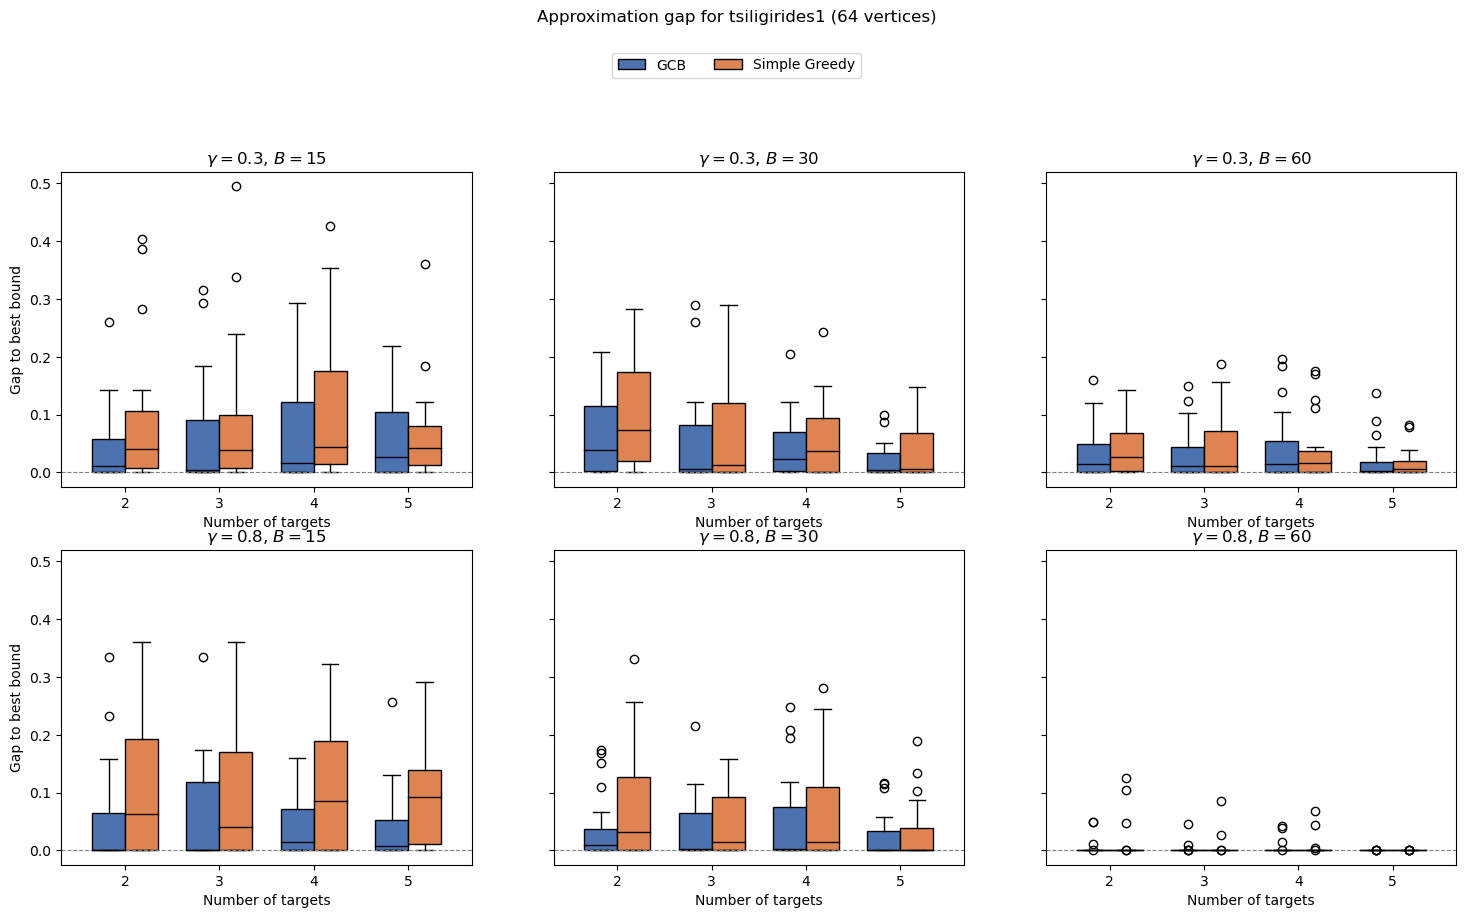

In [40]:
'''
Here, we present the results for every configuration using box plots
'''
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True)
axes = axes.flatten()

box_width = 0.35
positions_gcb = np.arange(len(target_counts)) - box_width / 2
positions_sg = np.arange(len(target_counts)) + box_width / 2

for idx, (ax, cfg, per_target) in enumerate(zip(axes, configs, all_results)):
    gcb_data = [per_target[n]["gcb"] for n in target_counts]
    sg_data = [per_target[n]["sg"] for n in target_counts]
    
    bp_gcb = ax.boxplot(gcb_data, positions=positions_gcb, widths=box_width,
                         patch_artist=True, boxprops=dict(facecolor="#4C72B0"),
                         medianprops=dict(color="black"))
    bp_sg = ax.boxplot(sg_data, positions=positions_sg, widths=box_width,
                        patch_artist=True, boxprops=dict(facecolor="#DD8452"),
                        medianprops=dict(color="black"))
    
    ax.set_xticks(np.arange(len(target_counts)))
    ax.set_xticklabels(target_counts)
    ax.set_xlabel("Number of targets")
    if idx % 3 == 0:
        ax.set_ylabel("Gap to best bound")
    ax.set_title(cfg["title"])
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")

fig.legend([bp_gcb["boxes"][0], bp_sg["boxes"][0]], ["GCB", "Simple Greedy"],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))

fig.suptitle(f"Approximation gap for {instance_class} (64 vertices)", y=1.06)

# # Save figure
# plt.tight_layout()
# plt.savefig(f"gap_boxplots_{instance_class}.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# # Save after the experiments finish

# results = {
#     "configs": configs,
#     "target_counts": target_counts,
#     "instance_class": instance_class,
#     "all_results": all_results,
# }

# with open(f"gap_results{instance_class}.pkl", "wb") as f:
#     pickle.dump(results, f)

### Results on trees

In [29]:
def tree_gurobi(inst: Instance, B: float, gamma: float, 
                  n_targets: int, softlimit: float = 90, hardlimit: float = 90) -> dict:
    
    cds = inst.coords
    prob = inst.probabilities
    dist = euc_dist(cds)
    '''
    The line below is the only one that changed in comparison to the previous MINLP for GSAP
    '''
    sym_dist = tree_dist(dist) 
       
    V = [i for i in cds.keys() if i != 0]
    T = range(n_targets)  
    
    m = gp.Model("G-SAP")
    m.setParam("OutputFlag", 0)  

    x = m.addVars(sym_dist.keys(), vtype=gp.GRB.BINARY, name="x")
    b = m.addVars(V, vtype=gp.GRB.INTEGER, name="b")
    q = m.addVars(n_targets, lb=0, ub=1, vtype=gp.GRB.CONTINUOUS, name="q")
    u = m.addVars(V, lb=1, ub=len(V), vtype=gp.GRB.INTEGER, name="u")
    
    fvals = [1 - (1-gamma)**k for k in range(B+1)]

    y = m.addVars(V, lb=0, ub=1, name="y")

    for i in V:
        m.addGenConstrPWL(
            b[i],
            y[i],
            list(range(B+1)),
            fvals
        )
    
    g = m.addVars(n_targets, lb=0, ub=1, name="g")

    for i in range(n_targets):
        m.addConstr(g[i] == 1 - q[i])

    prod_vars = []

    p = m.addVar(lb=0, ub=1, name="p_1")
    m.addQConstr(p == g[0] * g[1])

    prod_vars.append(p)

    for i in range(2, n_targets):

        new_p = m.addVar(lb=0, ub=1, name=f"p_{i}")

        m.addQConstr(new_p == prod_vars[-1] * g[i])

        prod_vars.append(new_p)

    prod = prod_vars[-1]

    m.setObjective(1 - prod, GRB.MAXIMIZE)
    
    for t in range(n_targets):
        m.addConstr(
            q[t] <= gp.quicksum(y[i] * prob[t, i] for i in V)
        )
    
    m.addConstr(gp.quicksum(x[i, j] for (i, j) in sym_dist.keys() if i == 0) == 1)

    m.addConstrs(gp.quicksum(x[i, j] for (i, j) in sym_dist.keys() if j == node) <= 1 for node in V)

    m.addConstrs(gp.quicksum(x[i, j] for (i, j) in sym_dist.keys() if i == node) <= 1 for node in V)

    m.addConstrs(gp.quicksum(x[i, j] for (i, j) in sym_dist.keys() if i == node) <=
                gp.quicksum(x[i, j] for (i, j) in sym_dist.keys() if j == node) for node in V)

    # m.addConstrs(x[i, j] + x[j, i] <= 1 for (i, j) in dist.keys() if i != 0)

    m.addConstrs((b[node] <= B * gp.quicksum(x[i, j] for (i, j) in sym_dist.keys() if j == node)) for node in V)

    m.addConstr(gp.quicksum(b[i] for i in V) + 
                 gp.quicksum(x[i, j] * sym_dist[i,j] for (i, j) in sym_dist.keys()) <= B)
    

    for (i, j) in sym_dist.keys():
        if i != 0 and j != 0:
            m.addConstr(u[i] - u[j] + len(V) * x[i, j] <= len(V) - 1)
    
    def softtime(model, where):
        if where == GRB.Callback.MIP:
            runtime = model.cbGet(GRB.Callback.RUNTIME)
            objbst = model.cbGet(GRB.Callback.MIP_OBJBST)
            objbnd = model.cbGet(GRB.Callback.MIP_OBJBND)
            if abs(objbst) > 1e-9:
                gap = abs(objbst - objbnd) / abs(objbst)
            else:
                gap = float("inf")
            if runtime > softlimit:
                model.terminate()
    
    m.setParam("TimeLimit", hardlimit)
    m.optimize(softtime)
    
    result = {
        "status": m.Status,
        "runtime": m.Runtime,
        "objective": m.ObjVal if m.SolCount > 0 else None,
        "best_bound": m.ObjBound,
        "mip_gap": m.MIPGap if m.SolCount > 0 else None,
        "n_targets": n_targets,
        "B": B,
        "gamma": gamma,
    }
    
    edges = []
    if m.SolCount > 0:
        for i, j in sym_dist.keys():
            if x[i, j].x > 0.5:
                edges.append((i, j))
    
    result["edges"] = edges
    result["allocation"] = [0] + [b[i].x for i in V]
    m.dispose()
    return result

In [30]:
path = r"C:\Thesis Econometrics\Benchmark Instances\tsiligirides1_targets5_random21.csv"
n_targets = 3
inst = read_test_instance(path, n_targets)

In [31]:
cds = inst.coords
prob = inst.probabilities
dist = euc_dist(cds)
sym_dist = tree_dist(dist)
V = [i for i in cds.keys() if i != 0]

In [32]:
B = 30
gamma = 0.3
results = tree_gurobi(inst, B, gamma, n_targets, 90, 90)
b = results["allocation"]
results["objective"]

0.39926707671847994

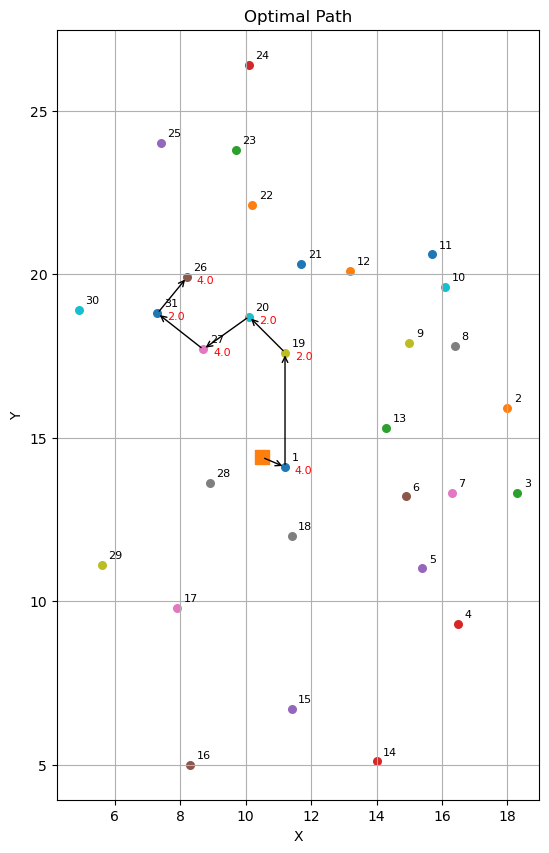

In [33]:
fig, ax = plt.subplots(figsize=(8, 10))

for node, (x_coord, y_coord) in cds.items():
    if node != 0:
        ax.scatter(x_coord, y_coord, s=30)
        ax.text(x_coord + 0.2, y_coord + 0.2, str(node), fontsize=8)

for i, j in results["edges"]:
    x1, y1 = cds[i]
    x2, y2 = cds[j]

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            lw=1,
        )
    )
    ax.text(x2+0.3, y2-0.2, str(b[j]), fontsize=8, color='r')

x0, y0 = cds[0]
ax.scatter(x0, y0, s=100, marker="s")

ax.set_title("Optimal Path")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
ax.set_aspect("equal")

plt.show()

In [34]:
final_path, cost, allocation = GCB(B, gamma, V, n_targets, prob, sym_dist)
final_path, cost, evaluate_obj(allocation, gamma, V, n_targets, prob)

([(0, 1), (1, 28), (28, 17), (17, 15)],
 29.916853435074696,
 0.37559275510100254)

In [35]:
(results["objective"]- evaluate_obj(allocation, gamma, V, n_targets, prob))/results["objective"]

0.059294449750410996

In [36]:
path, c, alloc = greedy(B, gamma, V, n_targets, prob, sym_dist)
path, evaluate_obj(alloc, gamma, V, n_targets, prob)

([1, 1, 1, 1, 1, 1, 28, 28, 28, 28, 28, 15, 15, 15, 15, 15, 15, 15],
 0.36150128247347724)

### Figures

In [61]:
benchmark_dir = r"C:\Thesis Econometrics\Benchmark Instances"
files = glob.glob(os.path.join(benchmark_dir, "*.csv"))

In [ ]:
# Again, we consider different problem parameters
configs = [
    {"gamma": 0.3, "B": 15, "title": r"$\gamma=0.3$, $B=15$"},
    {"gamma": 0.3, "B": 30, "title": r"$\gamma=0.3$, $B=30$"},
    {"gamma": 0.3, "B": 60, "title": r"$\gamma=0.3$, $B=60$"},
    {"gamma": 0.8, "B": 15, "title": r"$\gamma=0.8$, $B=15$"},
    {"gamma": 0.8, "B": 30, "title": r"$\gamma=0.8$, $B=30$"},
    {"gamma": 0.8, "B": 60, "title": r"$\gamma=0.8$, $B=60$"},
]

target_counts = [2, 3, 4, 5]
instance_class = "tsiligirides1" 

def collect_gaps(instance_class: str, gamma: float, B: float, n_targets: int, files: list) -> dict:
    
    gcb_gaps, sg_gaps = [], []
    n_opt = 0
    for filepath in files:
        filename = os.path.basename(filepath)
        if instance_class not in filename:
            continue
        
        inst = read_test_instance(filepath, n_targets)
        cds = inst.coords
        prob = inst.probabilities
        dist = euc_dist(cds)
        V = [i for i in cds.keys() if i != 0]
        sym_dist = tree_dist(dist) # Here, we use the distances along the minimum spanning tree
        
        gurobi_result = tree_gurobi(inst, B, gamma, n_targets, 90, 90)
        gcb_path, gcb_cost, gcb_allocation = GCB(B, gamma, V, n_targets, prob, sym_dist)
        sg_path, sg_cost, sg_allocation = greedy(B, gamma, V, n_targets, prob, sym_dist)
        
        if gurobi_result["status"] == GRB.OPTIMAL:
            n_opt += 1
            
        bb = gurobi_result["best_bound"]
        gcb_val = evaluate_obj(gcb_allocation, gamma, V, n_targets, prob)
        sg_val = evaluate_obj(sg_allocation, gamma, V, n_targets, prob)
        
        gcb_gaps.append((bb - gcb_val) / bb)
        sg_gaps.append((bb - sg_val) / bb)
    
    return {"gcb": gcb_gaps, "sg": sg_gaps}, {"n_opt" : n_opt}


all_results = []
n_opt_results = []
for cfg in configs:
    per_target = {}
    opt_reached = {}
    for n_targets in target_counts:
        gps = collect_gaps(
            instance_class, cfg["gamma"], cfg["B"], n_targets, files
        )
        per_target[n_targets] = gps[0]
        opt_reached[n_targets] = gps[1]
    all_results.append(per_target)
    n_opt_results.append(opt_reached)

In [62]:
with open("gap_resultstsiligirides1_ontrees.pkl", "rb") as f:
    results = pickle.load(f)

configs = results["configs"]
target_counts = results["target_counts"]
instance_class = results["instance_class"]
all_results = results["all_results"]

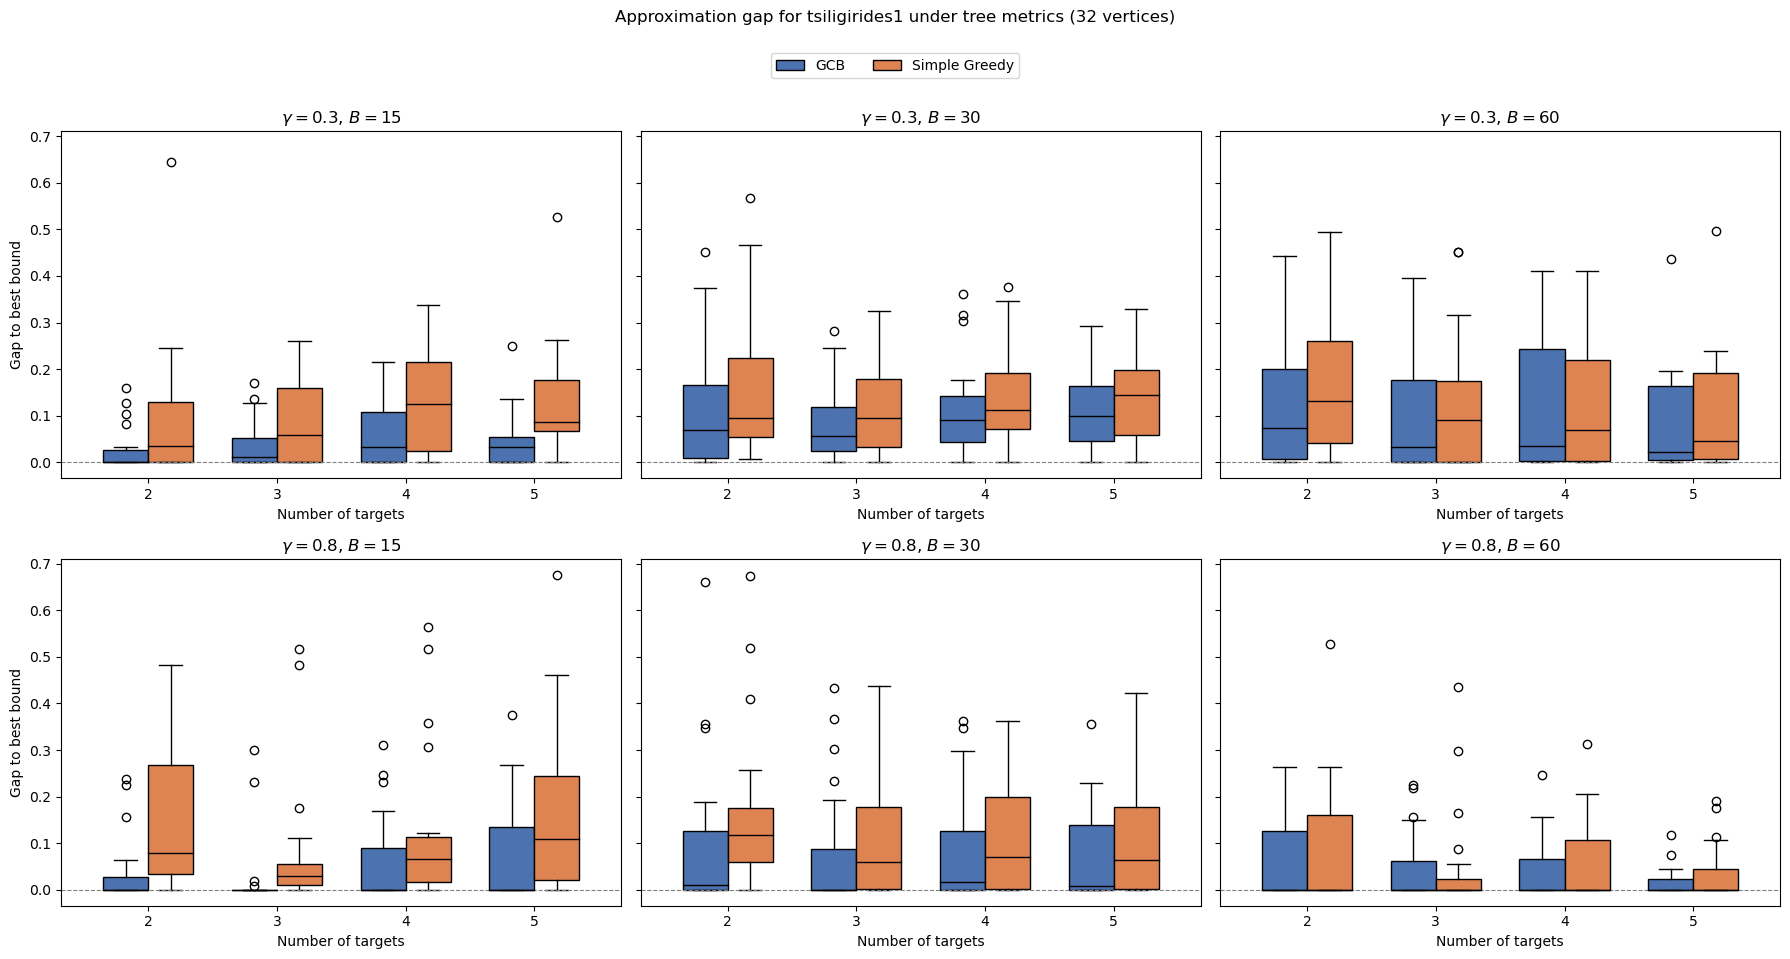

In [63]:
'''
The results are presented using box plots
'''
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True)
axes = axes.flatten()

box_width = 0.35
positions_gcb = np.arange(len(target_counts)) - box_width / 2
positions_sg = np.arange(len(target_counts)) + box_width / 2

for idx, (ax, cfg, per_target) in enumerate(zip(axes, configs, all_results)):
    gcb_data = [per_target[n]["gcb"] for n in target_counts]
    sg_data = [per_target[n]["sg"] for n in target_counts]
    
    bp_gcb = ax.boxplot(gcb_data, positions=positions_gcb, widths=box_width,
                         patch_artist=True, boxprops=dict(facecolor="#4C72B0"),
                         medianprops=dict(color="black"))
    bp_sg = ax.boxplot(sg_data, positions=positions_sg, widths=box_width,
                        patch_artist=True, boxprops=dict(facecolor="#DD8452"),
                        medianprops=dict(color="black"))
    
    ax.set_xticks(np.arange(len(target_counts)))
    ax.set_xticklabels(target_counts)
    ax.set_xlabel("Number of targets")
    if idx % 3 == 0:
        ax.set_ylabel("Gap to best bound")
    ax.set_title(cfg["title"])
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")

fig.legend([bp_gcb["boxes"][0], bp_sg["boxes"][0]], ["GCB", "Simple Greedy"],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))

fig.suptitle(f"Approximation gap for {instance_class} under tree metrics (32 vertices)", y=1.06)
plt.tight_layout()
plt.savefig(f"gap_boxplots_{instance_class}_ontrees.png", dpi=300, bbox_inches="tight")
plt.show()

### MST figure

In [37]:
path = r"C:\Thesis Econometrics\Benchmark Instances\tsiligirides1_targets5_random21.csv"
n_targets = 2
inst = read_test_instance(path, n_targets)
cds = inst.coords
dist = euc_dist(cds)

In [38]:
sym = {}
for (i, j), d in dist.items():
    if i != 0: 
        sym[i, j] = d
        sym[j, i] = d 
    else:
        sym[i, j] = d

In [39]:
G = nx.Graph()
for (i, j), d in sym.items():
    G.add_edge(i, j, weight=d)
T1 = nx.minimum_spanning_tree(G)

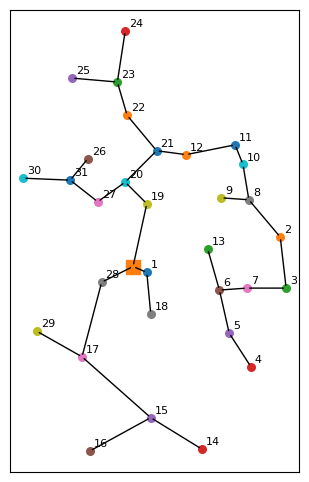

In [40]:
fig, ax = plt.subplots(figsize=(8, 6))

for node, (x_coord, y_coord) in cds.items():
    if node != 0:
        ax.scatter(x_coord, y_coord, s=30)
        ax.text(x_coord + 0.2, y_coord + 0.2 , str(node), fontsize=8, color="black")

for i, j, d in T1.edges.data():
    x1, y1 = cds[i]
    x2, y2 = cds[j]

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="-",
            lw=1,
        )
    )
#     ax.text(x2+0.3, y2-0.2, str(b[j]), fontsize=8, color='r')

x0, y0 = cds[0]
ax.scatter(x0, y0, s=100, marker="s")

ax.grid(True)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")
# fig.suptitle("Minimum spanning tree on Tsiligirides set 1", fontsize=10, fontweight="bold")
plt.savefig(f"MST Tsiligirides1.png", dpi=300, bbox_inches="tight")
plt.show()

### Visualization of benchmark sets

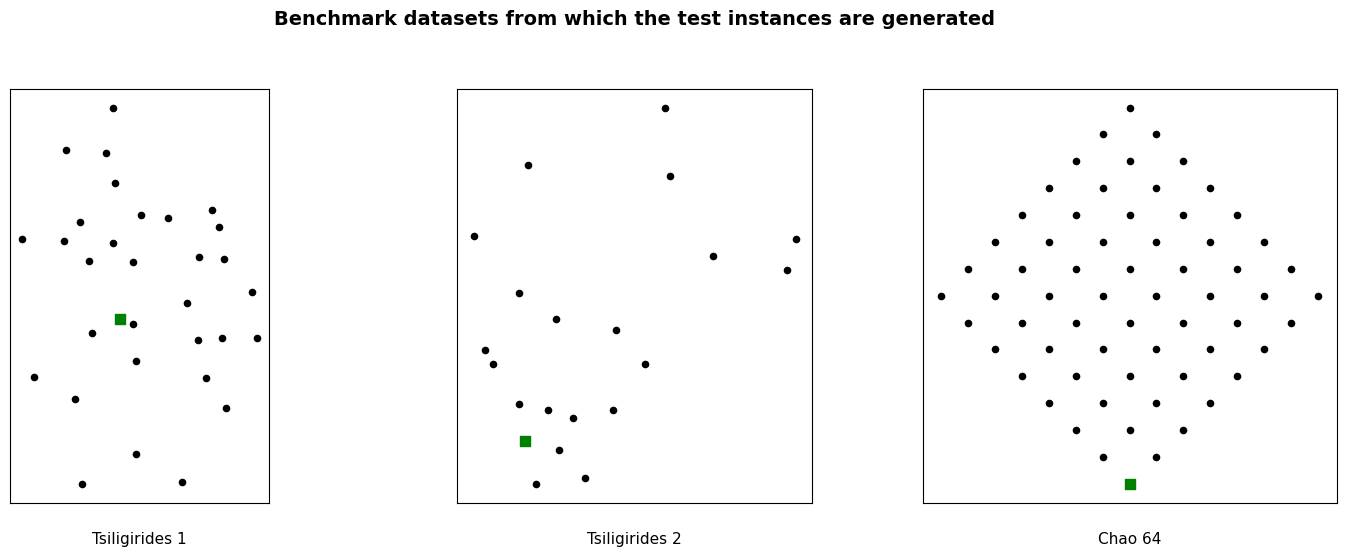

In [41]:
paths = [
    (r"C:\Thesis Econometrics\Benchmark Instances\tsiligirides1_targets5_random21.csv", "Tsiligirides 1"),
    (r"C:\Thesis Econometrics\Benchmark Instances\tsiligirides2_targets5_far21.csv", "Tsiligirides 2"),
    (r"C:\Thesis Econometrics\Benchmark Instances\chao1_targets5_close21.csv", "Chao 64"),
]

n_targets = 2

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, (path, name) in zip(axes, paths):
    inst = read_test_instance(path, n_targets)
    cds = inst.coords

    for node, (x, y) in cds.items():
        if node != 0:
            ax.scatter(x, y, s=20, color="black")
    
    x0, y0 = cds[0]
    ax.scatter(x0, y0, s=50, marker="s", color="green")

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(True)

    ax.set_title(name, y=-0.12, fontsize=11)

fig.suptitle("Benchmark datasets from which the test instances are generated", fontsize=14, fontweight="bold")

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig(f"Benchmark sets.png", dpi=300, bbox_inches="tight")
plt.show()